In [28]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
# Step 1: Create and connect to SQLite database
conn=sqlite3.connect("sales_data.db")
cursor=conn.cursor()

In [30]:
# Step 2: Create a simple sales table 
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL
)
''')

In [31]:
# Step 3:insert dummy data 
sample_data = [
    ('Apple', 10, 2.0),
    ('Banana', 20, 1.5),
    ('Orange', 15, 1.8),
    ('Apple', 5, 2.0),
    ('Banana', 10, 1.5)
]

In [32]:
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [33]:
# Step 4: Query total quantity and revenue by product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

In [34]:
# Step 5: Print the summary
print("Sales Summary:\n", df)

Sales Summary:
   product  total_qty  revenue
0   Apple         45     90.0
1  Banana         90    135.0
2  Orange         45     81.0


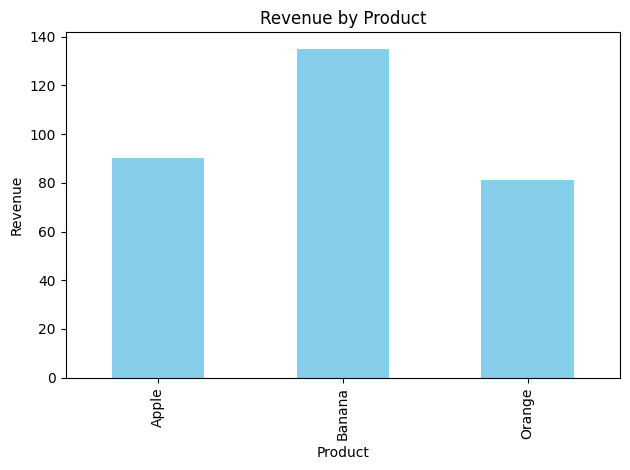

In [35]:
# Step 6: Plot revenue by product
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [36]:
# Close connection
conn.close()